In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from fredapi import Fred
import datetime
import os

# -------------------------------
# 1. Connect to FRED
# -------------------------------

# Option 1: Use environment variable
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

start = "1990-01-01"
end = datetime.datetime.today().strftime("%Y-%m-%d")

# -------------------------------
# 2. Download Data
# -------------------------------

series_codes = {
    "BAA": "BAA",                  # Moody's BAA corporate bond yield
    "GS10": "GS10",                # 10Y Treasury
    "UNRATE": "UNRATE",            # Unemployment rate
    "FEDFUNDS": "FEDFUNDS",        # Fed Funds rate
    "DRCCLACBS": "DRCCLACBS"       # C&I loan delinquency rate
}

df = pd.DataFrame()

for name, code in series_codes.items():
    df[name] = fred.get_series(code, observation_start=start, observation_end=end)

# Drop missing values
df = df.dropna()

# -------------------------------
# 3. Construct Credit Spread
# -------------------------------

df["SPREAD"] = df["BAA"] - df["GS10"]

print(df)

              BAA  GS10  UNRATE  FEDFUNDS  DRCCLACBS  SPREAD
1991-01-01  10.45  8.09     6.4      6.91       5.26    2.36
1991-04-01   9.94  8.04     6.7      5.91       5.48    1.90
1991-07-01   9.89  8.27     6.8      5.82       5.35    1.62
1991-10-01   9.49  7.53     7.0      5.21       5.32    1.96
1992-01-01   9.13  7.03     7.3      4.03       5.27    2.10
...           ...   ...     ...       ...        ...     ...
2024-07-01   5.84  4.25     4.2      5.33       3.20    1.59
2024-10-01   5.63  4.10     4.1      4.83       3.08    1.53
2025-01-01   6.08  4.63     4.0      4.33       3.06    1.45
2025-04-01   6.18  4.28     4.2      4.33       3.04    1.90
2025-07-01   6.10  4.39     4.3      4.33       2.98    1.71

[139 rows x 6 columns]


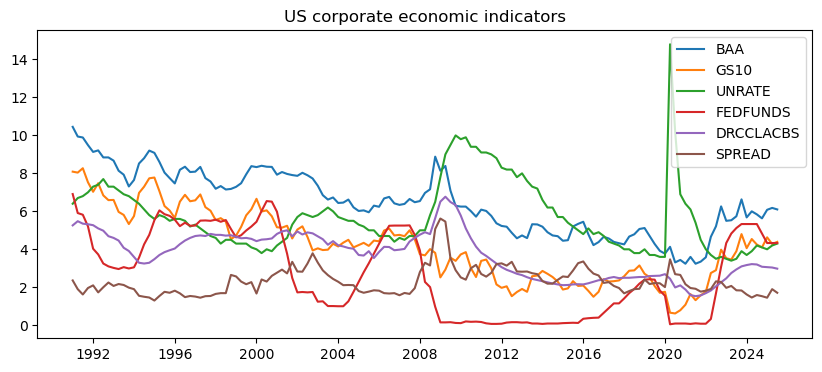

In [2]:
plt.figure(figsize=(10,4))
plt.plot(df, label = df.columns)
plt.title("US corporate economic indicators")
plt.legend()
plt.show()

In [3]:
# -------------------------------
# 4. Create Default Proxy
# -------------------------------

# High default regime = top 20% delinquency rate
threshold = df["DRCCLACBS"].quantile(0.80)
df["HIGH_DEFAULT"] = (df["DRCCLACBS"] > threshold).astype(int)

# Covariate matrix
X = df[["SPREAD", "UNRATE", "FEDFUNDS"]].values
X = np.column_stack([np.ones(len(X)), X])  # intercept
y = df["HIGH_DEFAULT"].values   # 1 = high default month, 0 = else

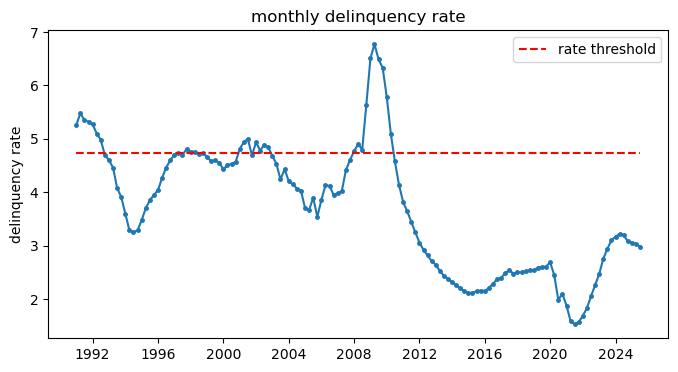

In [4]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df["DRCCLACBS"], marker='o', markersize=2.5)
plt.plot([df.index[0], df.index[-1]], [threshold] * 2, '--', c='red', label='rate threshold')
plt.title("monthly delinquency rate")
plt.ylabel("delinquency rate")
plt.legend()
plt.show()

predict months in which the corporate default rates are in the top 20% of the range

$$
\lambda_t = \exp\left(
\beta_0 
+ \beta_1 \,\text{Spread}_t 
+ \beta_2 \,\text{Unrate}_t 
+ \beta_3 \,\text{FedFunds}_t
\right)
$$

In [5]:
# -------------------------------
# 5. Log-Likelihood Function
# -------------------------------

beta_history, likelihood = [],[]

def neg_log_likelihood(beta):
    linear = X @ beta
    hazard = np.exp(linear)

    # Discrete-time exponential likelihood
    ll = y * np.log(hazard) - hazard
    ll_sum = -np.sum(ll)

    beta_history.append(beta)
    likelihood.append(ll_sum)
    
    return ll_sum

# -------------------------------
# 6. Maximum Likelihood Estimation
# -------------------------------

beta_init = np.zeros(X.shape[1])
result = minimize(neg_log_likelihood, beta_init, method="BFGS")

beta_hat = result.x

labels = ["constant","corporate bond spread", "unemployment rate", "FEDFUNDS rate"]

print("\nEstimated Parameters:")
for i, b in enumerate(beta_hat):
    print(f"Beta_{i}: {b:.6f} \t{labels[i]}")


Estimated Parameters:
Beta_0: -6.923708 	constant
Beta_1: 0.928901 	corporate bond spread
Beta_2: 0.262855 	unemployment rate
Beta_3: 0.459348 	FEDFUNDS rate


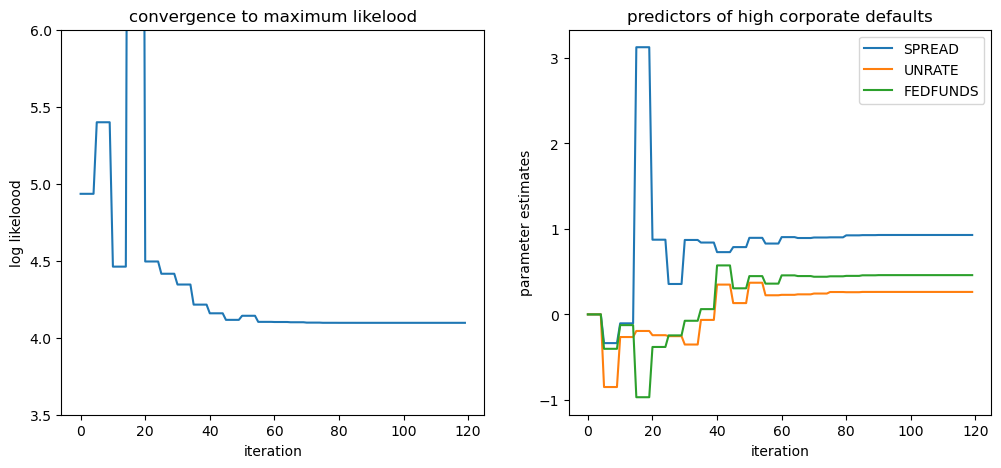

In [6]:
from math import log

fig,axs = plt.subplots(1,2,figsize=(12,5))
axs[0].plot([log(x) for x in likelihood]) 
axs[0].set_ylim(bottom=3.5,top=6)
axs[0].set_title("convergence to maximum likelood")
axs[0].set_xlabel("iteration")
axs[0].set_ylabel("log likeloood")

axs[1].set_title("predictors of high corporate defaults")
axs[1].plot([b[1:] for b in beta_history])
axs[1].legend(["SPREAD", "UNRATE", "FEDFUNDS"])
axs[1].set_xlabel("iteration")
axs[1].set_ylabel("parameter estimates")
plt.show()

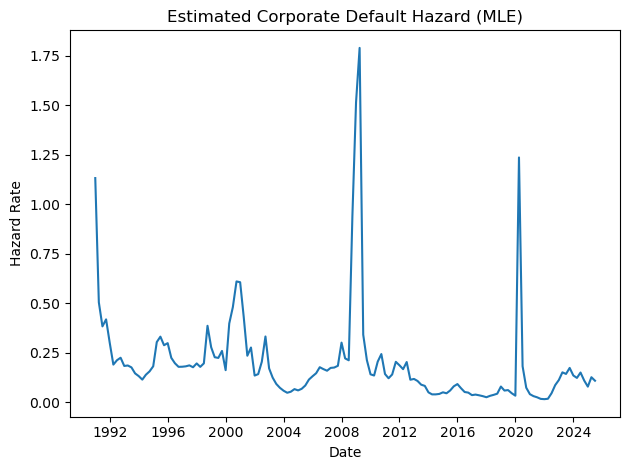

In [7]:
# -------------------------------
# 7. Compute Hazard Estimates
# -------------------------------

df["HAZARD_EST"] = np.exp(X @ beta_hat)

# -------------------------------
# 8. Plot Estimated Hazard
# -------------------------------

plt.figure()
plt.plot(df.index, df["HAZARD_EST"])
plt.title("Estimated Corporate Default Hazard (MLE)")
plt.xlabel("Date")
plt.ylabel("Hazard Rate")
plt.tight_layout()
plt.show()

In [8]:
!conda activate Rutgers